In [1]:
pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.9 MB/s eta 0:00:00


In [2]:
from faker import Faker

In [3]:
fake = Faker()

In [4]:
import pandas as pd
import numpy as np
import random
from faker import Faker
import matplotlib.pyplot as plt
import seaborn as sns


fake = Faker()

n = 100000

data = []

for i in range(n):
    age = random.randint(18, 70)
    gender = random.choice(['Male', 'Female'])
    tenure = random.randint(0, 10)
    balance = round(random.uniform(0, 200000), 2)
    credit_score = random.randint(300, 900)
    salary = round(random.uniform(10000, 150000), 2)
    products = random.randint(1, 4)
    active = random.choice([0, 1])


    churn = 1 if (balance < 50000 and active == 0 and credit_score < 500) else 0

    data.append([
        fake.uuid4(), age, gender, tenure, balance,
        credit_score, salary, products, active, churn
    ])

columns = [
    "Customer_ID", "Age", "Gender", "Tenure",
    "Balance", "CreditScore", "EstimatedSalary",
    "NumOfProducts", "IsActiveMember", "Churn"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("customer_churn_data.csv", index=False)

print("Dataset Created Successfully!")
df.head()

Dataset Created Successfully!


,Customer_ID,Age,Gender,Tenure,Balance,CreditScore,EstimatedSalary,NumOfProducts,IsActiveMember,Churn
0,beb14780-94c0-4df5-b92c-9d148ef54e4b,65,Male,10,71165.76,866,47984.03,4,1,0
1,8d843202-7c8f-4b91-bc95-e18784dac426,68,Male,3,199363.95,755,98626.14,4,1,0
2,80ed32b8-d0e3-4173-8cb4-305ad48f1983,45,Male,7,124391.75,726,94491.91,4,1,0
3,d9ac5d74-b596-4262-8b94-2d9215aa99a4,49,Female,5,64610.42,429,102715.76,1,1,0
4,f2bb23b5-6b7d-4ca7-834c-ba9bc7a0ecc1,55,Female,8,87025.69,620,24302.99,3,1,0


In [5]:
print(df.isnull().sum())

Customer_ID        0
Age                0
Gender             0
Tenure             0
Balance            0
CreditScore        0
EstimatedSalary    0
NumOfProducts      0
IsActiveMember     0
Churn              0
dtype: int64


In [6]:
print("Mean:\n", df.mean(numeric_only=True))
print("\nMedian:\n", df.median(numeric_only=True))
print("\nStd Dev:\n", df.std(numeric_only=True))

churn_rate = df['Churn'].value_counts(normalize=True) * 100
print(churn_rate)

Mean:
 Age                   44.049620
Tenure                 5.011050
Balance            99800.439033
CreditScore          599.709270
EstimatedSalary    79966.136095
NumOfProducts          2.498170
IsActiveMember         0.499780
Churn                  0.042870
dtype: float64

Median:
 Age                   44.000
Tenure                 5.000
Balance            99660.305
CreditScore          599.000
EstimatedSalary    79978.195
NumOfProducts          2.000
IsActiveMember         0.000
Churn                  0.000
dtype: float64

Std Dev:
 Age                   15.295880
Tenure                 3.157931
Balance            57852.077837
CreditScore          173.324787
EstimatedSalary    40316.322800
NumOfProducts          1.118351
IsActiveMember         0.500002
Churn                  0.202565
dtype: float64
Churn
0    95.713
1     4.287
Name: proportion, dtype: float64


/tmp/ipykernel_4123/3662184894.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


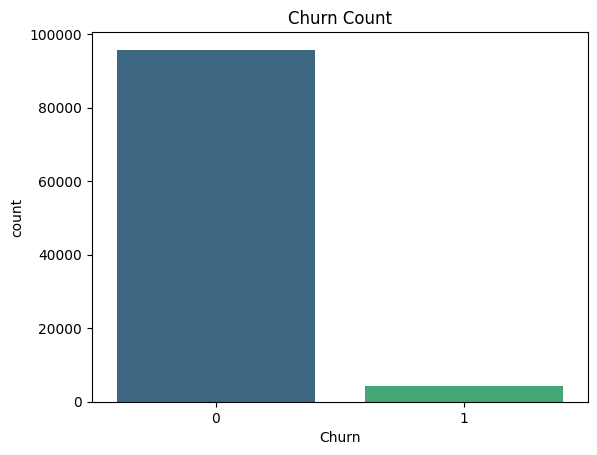

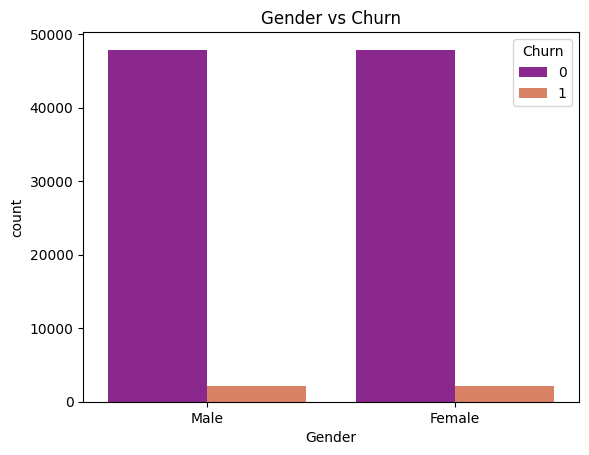

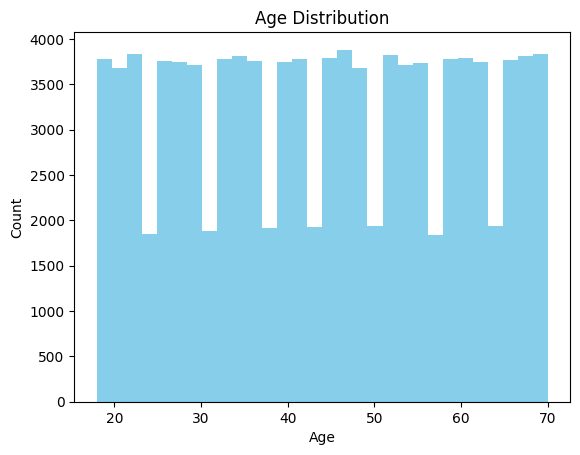

/tmp/ipykernel_4123/3662184894.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')


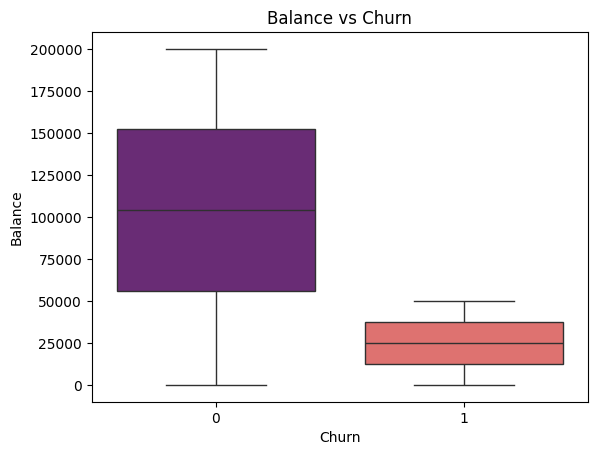

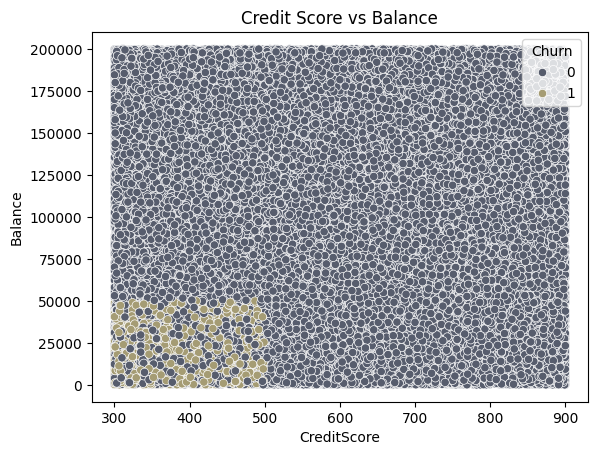

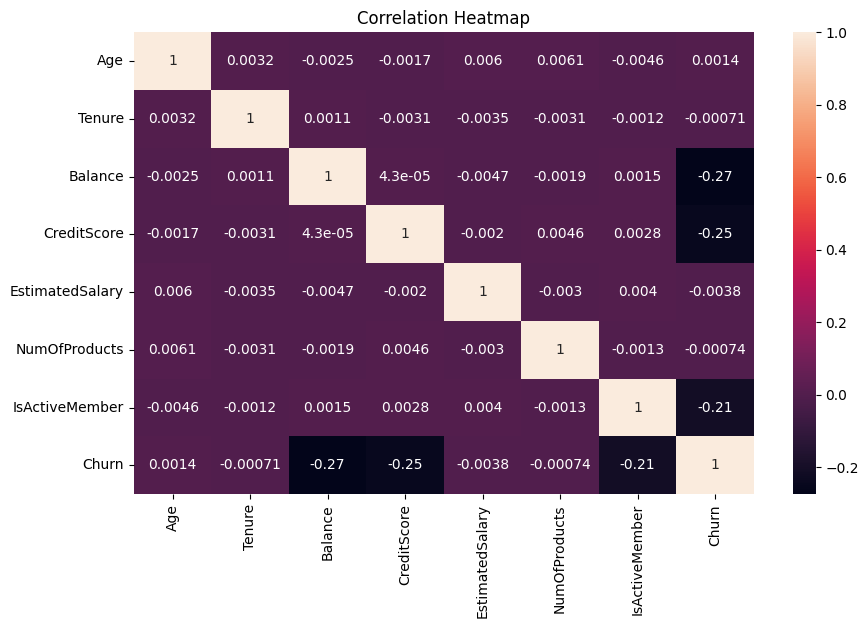

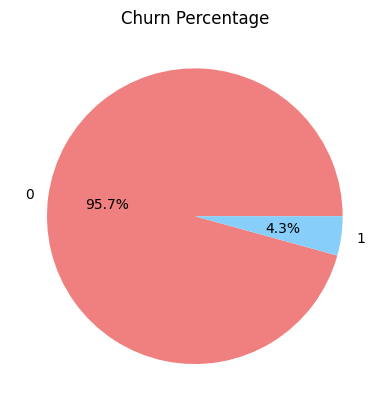

In [7]:
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title("Churn Count")
plt.show()
sns.countplot(x='Gender', hue='Churn', data=df, palette='plasma')
plt.title("Gender vs Churn")
plt.show()
plt.hist(df['Age'], bins=30, color='skyblue')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()
sns.boxplot(x='Churn', y='Balance', data=df, palette='magma')
plt.title("Balance vs Churn")
plt.show()
sns.scatterplot(x='CreditScore', y='Balance', hue='Churn', data=df, palette='cividis')
plt.title("Credit Score vs Balance")
plt.show()
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='rocket')
plt.title("Correlation Heatmap")
plt.show()
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title("Churn Percentage")
plt.ylabel("")
plt.show()